# Bias-Variance Tradeoff in Decision Trees

---

## The Core Tension

A decision tree learns by recursively partitioning the feature space. At one extreme, a **fully grown tree** creates one leaf per training sample — it fits the training data perfectly with zero training error. At the other extreme, a **stump** (depth 1) makes one split and produces a very coarse partition.

The problem is:

- A **deep tree** memorizes training data. It captures every noise fluctuation in the training set. When new data arrives, those memorized fluctuations are wrong — the model **overfits**.
- A **shallow tree** ignores most of the structure in the data. It produces the same rough prediction regardless of input — the model **underfits**.

This tension has a name: the **bias-variance tradeoff**.

The question we want to answer formally is:

> Can we decompose the expected prediction error into interpretable pieces, one for underfitting and one for overfitting?

The answer is yes, and the decomposition is exact.

---

## Setup: The Data Generating Process

Assume the true relationship between input $x$ and output $y$ is

$$
y = f(x) + \varepsilon,
$$

where:

- $f(x)$ is the **true unknown function** we are trying to learn.
- $\varepsilon$ is **irreducible noise** — random variation in $y$ that no model can explain.
- $\varepsilon$ satisfies:
  $$
  \mathbb{E}[\varepsilon] = 0, \qquad \text{Var}(\varepsilon) = \sigma^2.
  $$

We train a model $\hat{f}$ on a dataset $\mathcal{D}$ drawn from this process. The model produces predictions

$$
\hat{y}(x) = \hat{f}(x; \mathcal{D}).
$$

Because $\mathcal{D}$ is random (we got one particular sample of training data), $\hat{y}(x)$ is also a random variable — a different training set would produce a different tree and different predictions.

### Expected Prediction Error

For a fixed test point $x$, the **expected prediction error** (expected MSE) is

$$
\text{EPE}(x) = \mathbb{E}_{\mathcal{D},\, \varepsilon}\left[(y - \hat{y}(x))^2\right],
$$

where the expectation is taken over:
- All possible training datasets $\mathcal{D}$ of the same size.
- All possible noise realizations $\varepsilon$ at the test point.

This is the quantity we will decompose.

---

## The Full Bias-Variance Decomposition

### Starting Point

We want to expand

$$
\text{EPE}(x) = \mathbb{E}\left[(y - \hat{y})^2\right].
$$

We will drop the explicit $x$ for readability. All expectations are over $\mathcal{D}$ and $\varepsilon$.

Define the **expected prediction** of our model:

$$
\bar{y} = \mathbb{E}_{\mathcal{D}}[\hat{y}].
$$

This is the average prediction the model would make if we trained it on many different datasets of the same size.

---

### Step 1: Substitute $y = f + \varepsilon$

Replace $y$ with $f + \varepsilon$:

$$
\mathbb{E}\left[(y - \hat{y})^2\right]
= \mathbb{E}\left[(f + \varepsilon - \hat{y})^2\right].
$$

Regroup by adding and subtracting $\bar{y}$:

$$
= \mathbb{E}\left[(f + \varepsilon - \hat{y} + \bar{y} - \bar{y})^2\right].
$$

Group into two parts:

$$
= \mathbb{E}\left[\big((f - \bar{y}) + (\bar{y} - \hat{y}) + \varepsilon\big)^2\right].
$$

Label three pieces:

$$
A = f - \bar{y}, \qquad B = \bar{y} - \hat{y}, \qquad C = \varepsilon.
$$

So we need to expand $\mathbb{E}[(A + B + C)^2]$.

---

### Step 2: Expand the Square

By the expansion $(A + B + C)^2 = A^2 + B^2 + C^2 + 2AB + 2AC + 2BC$:

$$
\mathbb{E}[(A + B + C)^2]
= \mathbb{E}[A^2] + \mathbb{E}[B^2] + \mathbb{E}[C^2]
+ 2\mathbb{E}[AB] + 2\mathbb{E}[AC] + 2\mathbb{E}[BC].
$$

We now simplify each term.

---

### Step 3: Simplify Each Term

**Term $\mathbb{E}[A^2]$:**

$A = f - \bar{y}$ is a **constant** with respect to $\mathcal{D}$ and $\varepsilon$ (both $f$ and $\bar{y}$ are fixed numbers for a given $x$). So:

$$
\mathbb{E}[A^2] = (f - \bar{y})^2.
$$

This is the **squared bias**.

---

**Term $\mathbb{E}[B^2]$:**

$B = \bar{y} - \hat{y}$. Here $\bar{y}$ is a constant (the average prediction) and $\hat{y}$ is random over $\mathcal{D}$:

$$
\mathbb{E}[B^2]
= \mathbb{E}\left[(\bar{y} - \hat{y})^2\right]
= \mathbb{E}\left[(\hat{y} - \bar{y})^2\right].
$$

This is the **variance** of the model's predictions.

---

**Term $\mathbb{E}[C^2]$:**

$C = \varepsilon$. Since $\mathbb{E}[\varepsilon] = 0$:

$$
\mathbb{E}[C^2] = \mathbb{E}[\varepsilon^2] = \text{Var}(\varepsilon) = \sigma^2.
$$

This is the **irreducible noise**.

---

**Cross term $\mathbb{E}[AB]$:**

$A = f - \bar{y}$ is a constant. $B = \bar{y} - \hat{y}$. Take expectation over $\mathcal{D}$:

$$
\mathbb{E}[AB]
= (f - \bar{y}) \cdot \mathbb{E}[\bar{y} - \hat{y}]
= (f - \bar{y}) \cdot (\bar{y} - \mathbb{E}[\hat{y}])
= (f - \bar{y}) \cdot (\bar{y} - \bar{y})
= 0.
$$

---

**Cross term $\mathbb{E}[AC]$:**

$A = f - \bar{y}$ is a constant with respect to $\varepsilon$. $C = \varepsilon$ is independent of $\mathcal{D}$ and has mean zero:

$$
\mathbb{E}[AC]
= (f - \bar{y}) \cdot \mathbb{E}[\varepsilon]
= (f - \bar{y}) \cdot 0
= 0.
$$

---

**Cross term $\mathbb{E}[BC]$:**

$B = \bar{y} - \hat{y}$ depends only on $\mathcal{D}$. $C = \varepsilon$ is independent of $\mathcal{D}$ and has mean zero. By independence:

$$
\mathbb{E}[BC]
= \mathbb{E}_{\mathcal{D}}[\bar{y} - \hat{y}] \cdot \mathbb{E}_{\varepsilon}[\varepsilon]
= (\bar{y} - \bar{y}) \cdot 0
= 0.
$$

---

### Step 4: Collect the Terms

All three cross terms are zero. What remains is:

$$
\text{EPE}(x)
= \underbrace{(f - \bar{y})^2}_{\text{Bias}^2}
+ \underbrace{\mathbb{E}\left[(\hat{y} - \bar{y})^2\right]}_{\text{Variance}}
+ \underbrace{\sigma^2}_{\text{Irreducible noise}}.
$$

Written cleanly:

$$
\boxed{
\mathbb{E}\left[(y - \hat{y})^2\right]
= \left(\mathbb{E}[\hat{y}] - f(x)\right)^2
+ \mathbb{E}\left[\left(\hat{y} - \mathbb{E}[\hat{y}]\right)^2\right]
+ \sigma^2
}
$$

or in shorthand:

$$
\text{EPE} = \text{Bias}^2 + \text{Variance} + \sigma^2.
$$

This decomposition is **exact** — there are no approximations.

---

## What Each Term Means for Decision Trees

### Bias

$$
\text{Bias}^2 = \left(\mathbb{E}_{\mathcal{D}}[\hat{f}(x)] - f(x)\right)^2
$$

Bias measures how far the **average prediction** of our model is from the **true function** $f(x)$.

In a decision tree:

- A **shallow tree** (small depth) can only partition the feature space into a few coarse regions. If the true function $f(x)$ has fine-grained structure, a shallow tree cannot represent it — no matter how much training data you give it, its average prediction will always be far from the truth. This is **high bias**.
- A **deep tree** makes very fine partitions and can approximate $f(x)$ closely on average. This is **low bias**.

**High bias = underfitting = the model is too simple to represent the true function.**

---

### Variance

$$
\text{Variance} = \mathbb{E}_{\mathcal{D}}\left[\left(\hat{f}(x) - \mathbb{E}_{\mathcal{D}}[\hat{f}(x)]\right)^2\right]
$$

Variance measures how much the model's predictions **fluctuate** when trained on different datasets of the same size.

In a decision tree:

- A **deep tree** is highly sensitive to which specific samples land in each leaf. A few different training points can produce a completely different partition of the feature space — and therefore completely different predictions. This is **high variance**.
- A **shallow tree** produces the same few coarse regions regardless of training data fluctuations. This is **low variance**.

**High variance = overfitting = the model memorizes noise in the training set.**

---

### Irreducible Noise $\sigma^2$

$$
\sigma^2 = \text{Var}(\varepsilon)
$$

This is the variance of the noise in the data generating process itself. It exists regardless of what model you use or how deep your tree is.

- No model can predict noise.
- No amount of data or model complexity can reduce $\sigma^2$.
- It is a **lower bound** on the expected prediction error.

**$\sigma^2$ sets the floor — you cannot go below it.**

---

## The Tradeoff and the U-Shaped Error Curve

Bias and variance move in **opposite directions** as model complexity changes:

- Increasing depth → **lower bias, higher variance**
- Decreasing depth → **higher bias, lower variance**

Total expected error is their sum plus $\sigma^2$. There is an **optimal complexity** where total error is minimized — neither too shallow nor too deep.

The classic picture is the **U-shaped test error curve**:

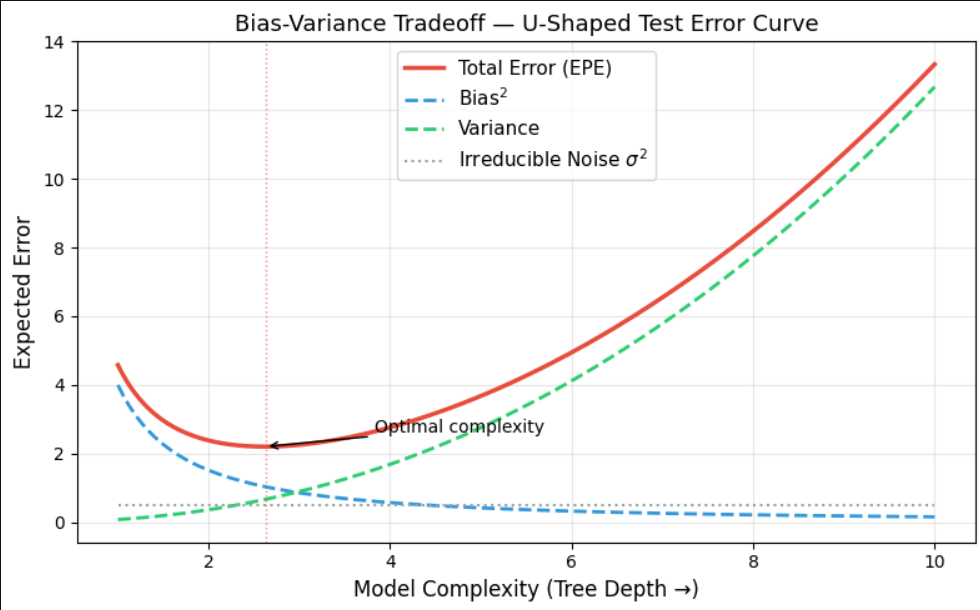

The red curve (total error) is U-shaped:
- Left side: bias dominates, tree is too shallow.
- Right side: variance dominates, tree is too deep.
- Bottom of the U: optimal depth.

---

## Connection to Pruning

The bias-variance decomposition gives a principled justification for **pruning** a decision tree.

A **fully grown tree** (no stopping criterion) has:

- Near-zero bias — it can fit $f(x)$ very closely on average.
- Very high variance — it is extremely sensitive to the exact training samples.

Because variance is so high, the total expected test error is large even though the training error is near zero.

**Pruning** removes leaf nodes (or subtrees) that contribute little to reducing bias, but contribute significantly to variance. Specifically:

- Each removed split **increases bias slightly** — we are using a coarser partition.
- Each removed split **decreases variance more significantly** — fewer splits mean predictions are less sensitive to training set fluctuations.
- The net effect is a **reduction in total expected test error**.

Formally, pruning navigates the bias-variance curve from right to left:

$$
\text{EPE}_{\text{pruned}} = \underbrace{\text{Bias}^2 + \delta_{\text{bias}}}_{\text{slightly higher bias}} + \underbrace{\text{Variance} - \delta_{\text{var}}}_{\text{much lower variance}} + \sigma^2,
$$

where $\delta_{\text{var}} \gg \delta_{\text{bias}}$ for well-chosen pruning decisions. The total error goes down.

This is the entire theoretical justification for **post-pruning** in CART: a fully grown tree gives high variance; pruning finds the right point on the bias-variance curve by exchanging a small amount of bias for a large reduction in variance.

> **Key insight:** Pruning is not just a regularization trick — it is the direct algorithmic consequence of the bias-variance decomposition applied to decision trees.